In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)


In [2]:
digit=load_digits()

In [3]:
dir(digit)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [4]:
df=pd.DataFrame(digit.data,columns=digit.feature_names)

In [5]:
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


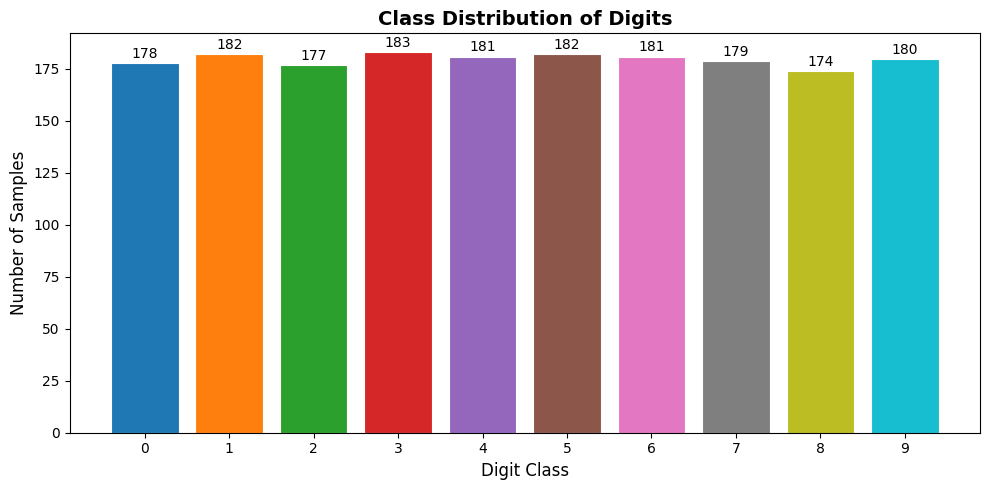

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
counts = df['target'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values,
              color=plt.cm.tab10(np.linspace(0, 1, 10)),
              edgecolor='white', linewidth=0.8)
ax.set_xlabel("Digit Class", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_title("Class Distribution of Digits", fontsize=14, fontweight='bold')
ax.set_xticks(range(10))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [6]:
df.isnull().sum()

pixel_0_0    0
pixel_0_1    0
pixel_0_2    0
pixel_0_3    0
pixel_0_4    0
            ..
pixel_7_3    0
pixel_7_4    0
pixel_7_5    0
pixel_7_6    0
pixel_7_7    0
Length: 64, dtype: int64

In [7]:
#check the target 
df['target']=digit.target

In [8]:
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [9]:
x=df.drop(df[['target']],axis='columns')

In [10]:
x

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [11]:
y=df['target']

In [12]:
y

0       0
1       1
2       2
3       3
4       4
       ..
1792    9
1793    0
1794    8
1795    9
1796    8
Name: target, Length: 1797, dtype: int64

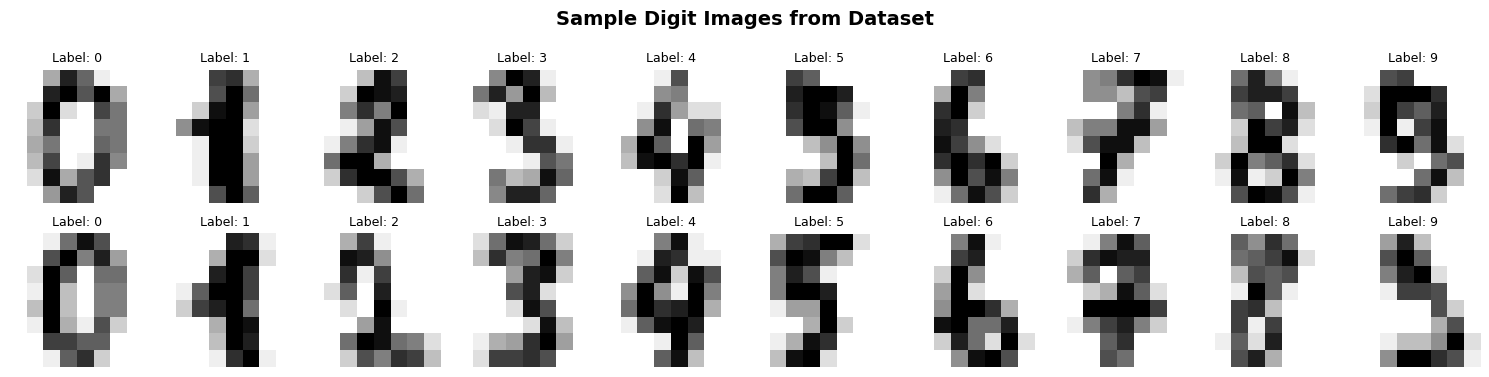

In [13]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
fig.suptitle("Sample Digit Images from Dataset", fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(digit.images[i], cmap='gray_r')
    ax.set_title(f"Label: {digit.target[i]}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig("sample_digits.png", dpi=150, bbox_inches='tight')
plt.show()
 

In [18]:
# train test split
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test =train_test_split(x,y,test_size=.3,random_state=42)

In [20]:
# import svm classifier model 
from sklearn.svm import SVC

In [21]:
model=SVC()

In [22]:
model.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


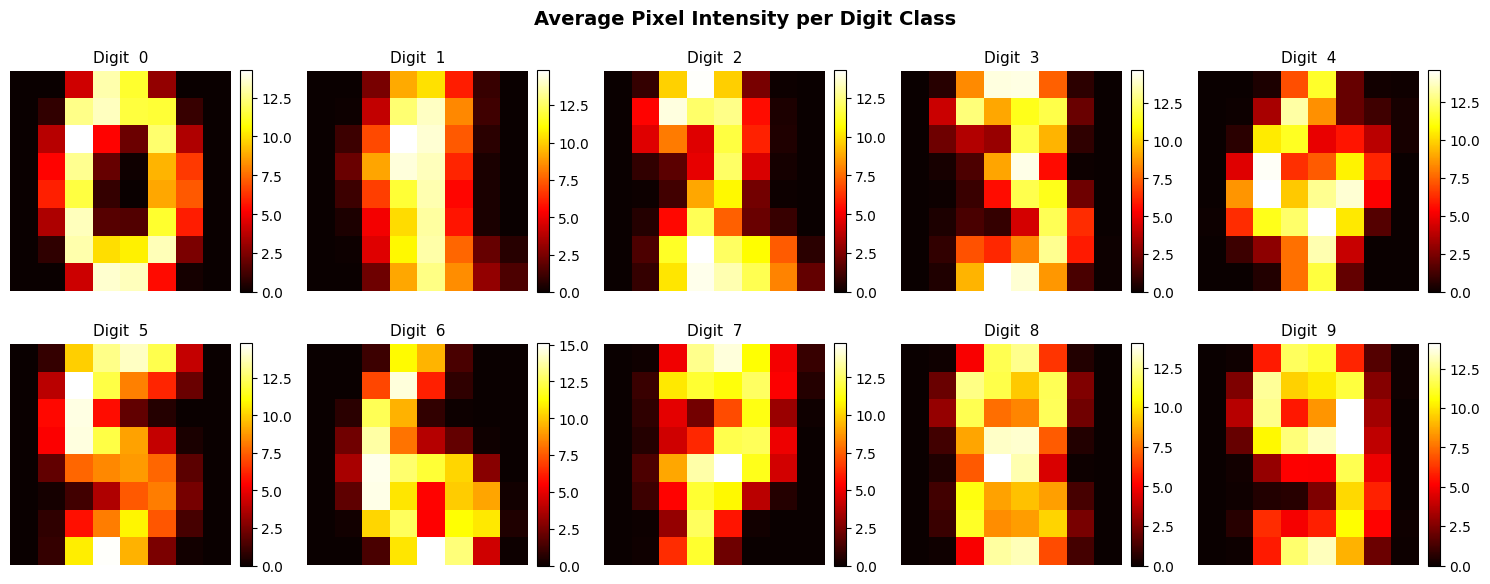

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Average Pixel Intensity per Digit Class", fontsize=14, fontweight='bold')
for digit_class, ax in zip(range(10), axes.flat):
    avg_image = digit.data[digit.target == digit_class].mean(axis=0).reshape(8, 8)
    im = ax.imshow(avg_image, cmap='hot', interpolation='nearest')
    ax.set_title(f"Digit  {digit_class}", fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("avg_pixel_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
 

In [24]:
model.score(X_test,y_test)

0.987037037037037

In [25]:
# importing pickle for model saving 
import pickle


In [26]:
with open ("model_pickle",'wb') as f:
    pickle.dump(model,f)

In [27]:
with open ("model_pickle", 'rb') as f:
    model=pickle.load(f)

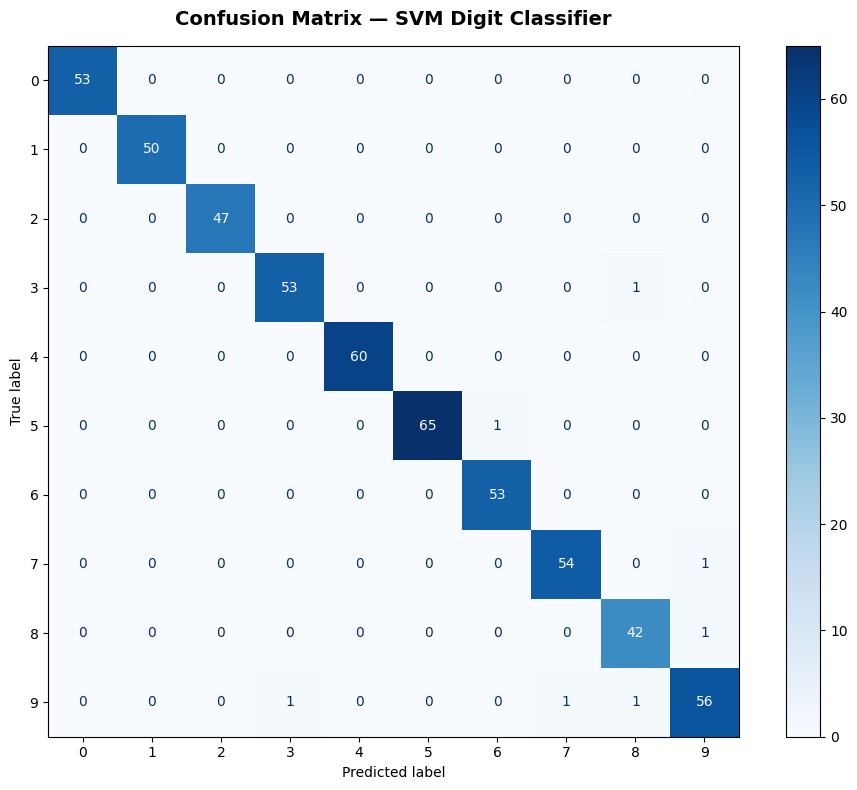

In [28]:
y_pred = model.predict(X_test)
 
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=digit.target_names)
disp.plot(cmap='Blues', ax=ax, colorbar=True)
ax.set_title("Confusion Matrix — SVM Digit Classifier",
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

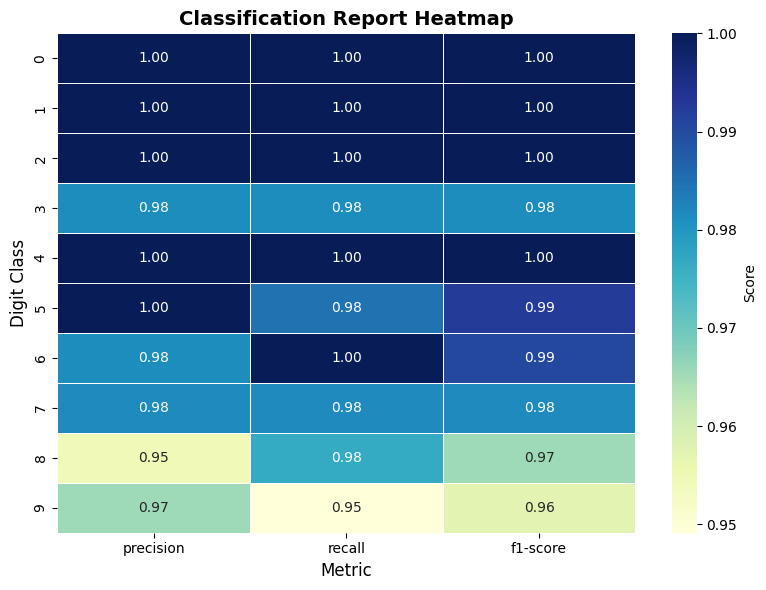

In [29]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().iloc[:10, :3]   # digits 0-9 only
 
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(report_df.astype(float), annot=True, fmt=".2f",
            cmap='YlGnBu', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Score'})
ax.set_title("Classification Report Heatmap", fontsize=14, fontweight='bold')
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Digit Class", fontsize=12)
plt.tight_layout()
plt.savefig("classification_report_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

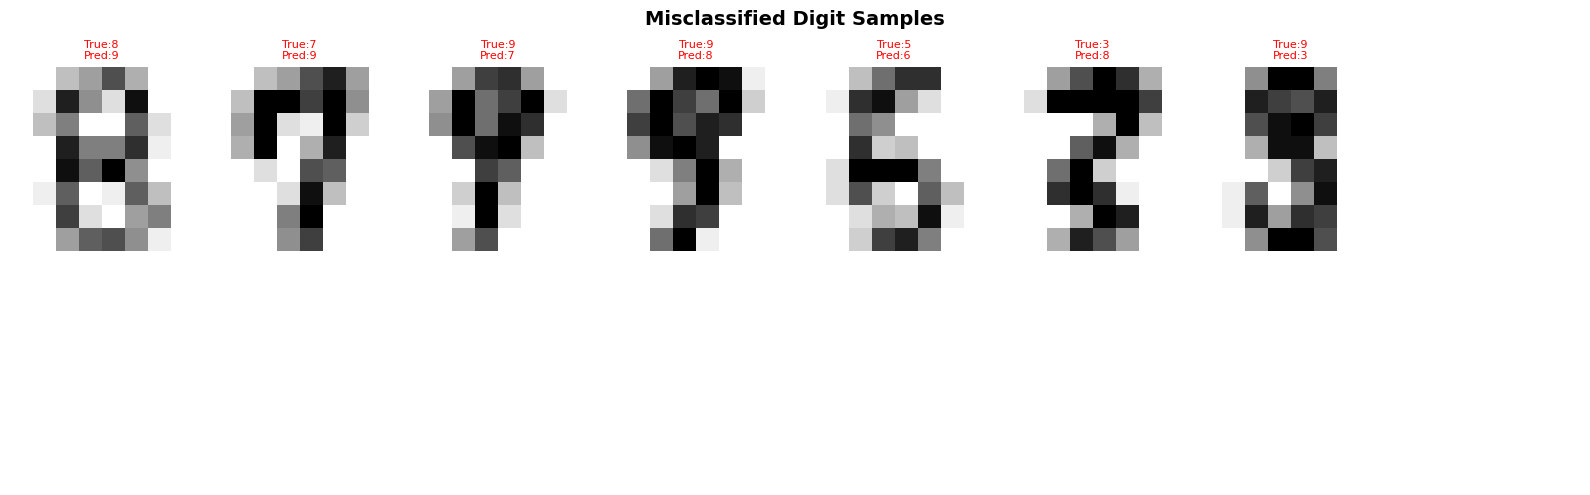

In [30]:
X_test_arr = X_test.to_numpy()
y_test_arr = y_test.to_numpy()
misclassified_idx = np.where(y_pred != y_test_arr)[0]
 
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Misclassified Digit Samples", fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i < len(misclassified_idx):
        idx = misclassified_idx[i]
        ax.imshow(X_test_arr[idx].reshape(8, 8), cmap='gray_r')
        ax.set_title(f"True:{y_test_arr[idx]}\nPred:{y_pred[idx]}",
                     fontsize=8, color='red')
    ax.axis('off')
plt.tight_layout()
plt.savefig("misclassified_samples.png", dpi=150, bbox_inches='tight')
plt.show()
 

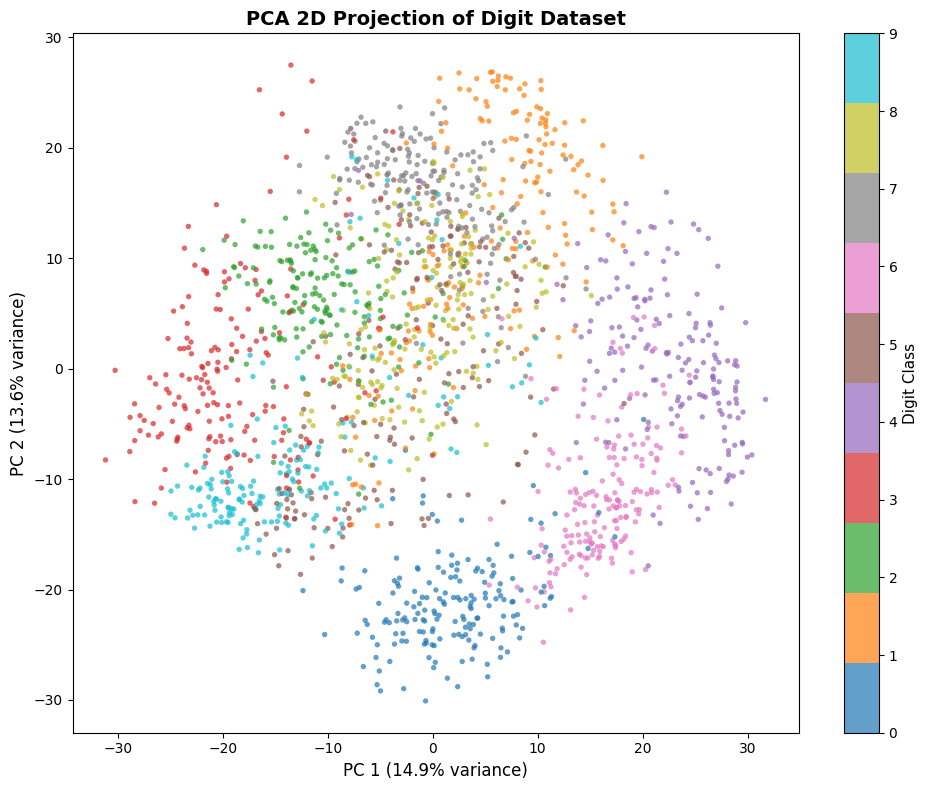

In [31]:
from sklearn.decomposition import PCA
 
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(digit.data)
 
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=digit.target, cmap='tab10',
                     alpha=0.7, s=15, edgecolors='none')
cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label("Digit Class", fontsize=11)
cbar.set_ticklabels([str(i) for i in range(10)])
ax.set_title("PCA 2D Projection of Digit Dataset", fontsize=14, fontweight='bold')
ax.set_xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=12)
plt.tight_layout()
plt.savefig("pca_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

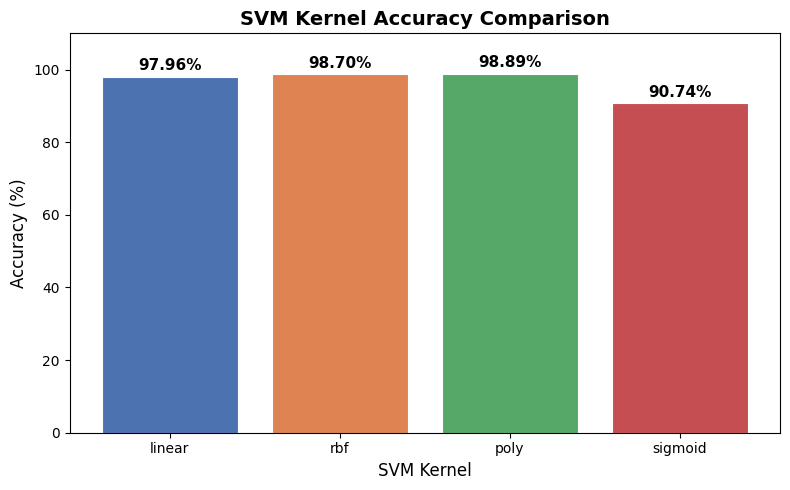

In [32]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
accuracies = []
for k in kernels:
    m = SVC(kernel=k)
    m.fit(X_train, y_train)
    accuracies.append(m.score(X_test, y_test) * 100)
 
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax.bar(kernels, accuracies, color=colors, edgecolor='white', linewidth=0.8)
ax.set_ylim(0, 110)
ax.set_xlabel("SVM Kernel", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("SVM Kernel Accuracy Comparison", fontsize=14, fontweight='bold')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1, f"{acc:.2f}%",
            ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig("kernel_comparison.png", dpi=150, bbox_inches='tight')
plt.show()